# Overfitting and Regularization in Logistic Regression

In this notebook, I explore how logistic regression can overfit when the model becomes too flexible.

I first create polynomial features to allow the model to learn a more complex decision boundary. Then I add regularization to reduce overfitting.

Main ideas covered:

- Underfitting
- Overfitting
- Polynomial features
- Regularized cost function
- Regularized gradient descent
- The effect of lambda

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## What is Overfitting?

Overfitting happens when a model fits the training data too closely.

Instead of learning the general pattern, the model starts memorizing the training examples.

A model can usually have three cases:

- Underfitting: the model is too simple and performs poorly
- Good fit: the model captures the general pattern
- Overfitting: the model is too complex and memorizes the training data

Regularization helps reduce overfitting by discouraging very large parameter values.

In [2]:
X = np.array([
    [0.1, 0.6],
    [0.2, 0.7],
    [0.3, 0.8],
    [0.4, 0.7],
    [0.5, 0.6],
    [0.6, 0.5],
    [0.7, 0.4],
    [0.8, 0.3],
    [0.9, 0.2],
    [0.2, 0.2],
    [0.3, 0.3],
    [0.4, 0.4],
    [0.5, 0.3],
    [0.6, 0.2],
    [0.7, 0.1],
    [0.8, 0.8],
    [0.9, 0.9],
    [0.1, 0.1]
])

y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1,
              0, 0, 0, 0, 0, 0, 0, 0, 0])

print(X.shape)
print(y.shape)

(18, 2)
(18,)


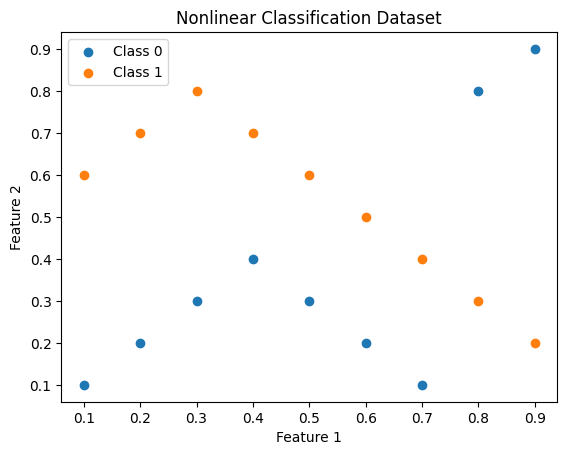

In [3]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Classification Dataset")
plt.legend()
plt.show()

## Polynomial Features

A straight decision boundary may not be enough for nonlinear data.

To make logistic regression more flexible, we can create polynomial features.

For example, if the original features are:

$$
x_1, x_2
$$

we can add features like:

$$
x_1^2, x_2^2, x_1x_2
$$

This allows the model to learn curved decision boundaries.

However, adding too many polynomial features can make the model overfit.

In [4]:
def map_features(X):
    x1 = X[:, 0]
    x2 = X[:, 1]

    X_mapped = np.column_stack([
        x1,
        x2,
        x1**2,
        x2**2,
        x1 * x2,
        x1**3,
        x2**3,
        (x1**2) * x2,
        x1 * (x2**2)
    ])

    return X_mapped

In [5]:
X_mapped = map_features(X)

m, n = X_mapped.shape

w = np.zeros(n)
b = 0

print("Mapped X shape:", X_mapped.shape)
print("w shape:", w.shape)

Mapped X shape: (18, 9)
w shape: (9,)


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Regularized Cost Function

The normal logistic regression cost is:

$$
J(w,b) = -\frac{1}{m} \sum
\left[
y\log(f) + (1-y)\log(1-f)
\right]
$$

With regularization, we add a penalty for large weights:

$$
J(w,b) = \text{normal cost} + \frac{\lambda}{2m}\sum w_j^2
$$

The bias term `b` is not regularized.

The parameter `lambda` controls how strong the regularization is.

- Small lambda: weaker regularization
- Large lambda: stronger regularization

In [7]:
def compute_cost_reg(X, y, w, b, lambda_):
    m = X.shape[0]
    f = sigmoid(np.dot(X,w) + b)

    f = np.clip(f, 1e-15, 1 - 1e-15)
    cost = np.sum(y*np.log(f) + (1-y)*np.log(1-f)) / -m
    total_cost = cost + (np.dot(w,w) * (lambda_/(2*m)))


    return total_cost

In [8]:
def compute_gradient_reg(X, y, w, b, lambda_):
    m = X.shape[0]
    f = sigmoid(np.dot(X,w) + b)

    dj_dw = np.dot(f-y,X) / m
    dj_db = np.sum(f-y) / m
    dj_dw = dj_dw + (w * (lambda_/ m ))

    return dj_dw, dj_db

In [9]:
def gradient_descent_reg(X, y, w, b, alpha, iterations, lambda_):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient_reg(X, y, w, b, lambda_)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 100 == 0:
            cost = compute_cost_reg(X, y, w, b, lambda_)
            cost_history.append(cost)

    return w, b, cost_history

In [10]:
alpha = 0.5
iterations = 1000
lambda_ = 1

w_final, b_final, cost_history = gradient_descent_reg(
    X_mapped, y, w, b, alpha, iterations, lambda_
)

print("Final w:", w_final)
print("Final b:", b_final)

Final w: [ 0.03255729  0.56733595  0.03276815  0.32188819 -0.10678453  0.02528877
  0.09792154 -0.26062174 -0.24974589]
Final b: -0.29328005189339307


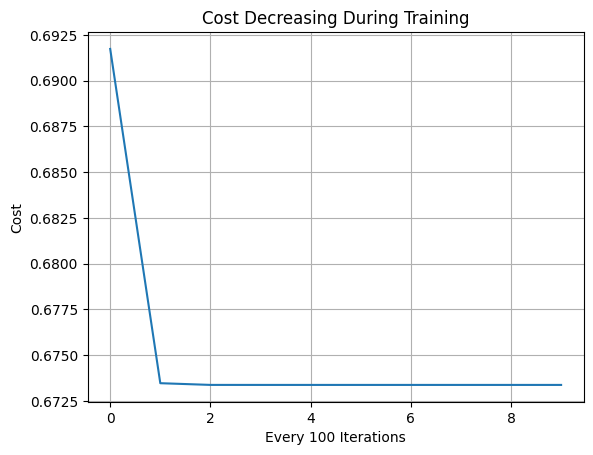

In [11]:
plt.plot(cost_history)

plt.xlabel("Every 100 Iterations")
plt.ylabel("Cost")
plt.title("Cost Decreasing During Training")
plt.grid(True)
plt.show()

In [12]:
def predict(X, w, b):
    probabilities = sigmoid(np.dot(X, w) + b)
    predictions = probabilities >= 0.5

    return predictions.astype(int)

In [13]:
predictions = predict(X_mapped, w_final, b_final)

accuracy = np.mean(predictions == y) * 100

print("Predictions:", predictions)
print("Actual labels:", y)
print(f"Accuracy:{accuracy:.4f}")

Predictions: [1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0]
Actual labels: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
Accuracy:72.2222


## Effect of Lambda

The regularization parameter `lambda` controls how much we penalize large weights.

If lambda is too small, the model may overfit.

If lambda is too large, the model may underfit.

A good lambda helps the model learn the general pattern without becoming too sensitive to individual training examples.

In [14]:
lambda_values = [0, 0.001, 0.01, 0.03, 0.1, 0.3, 1]

for lambda_ in lambda_values:
    w_temp = np.zeros(n)
    b_temp = 0

    w_temp, b_temp, cost_history = gradient_descent_reg(
        X_mapped, y, w_temp, b_temp, alpha, iterations, lambda_
    )

    predictions = predict(X_mapped, w_temp, b_temp)
    accuracy = np.mean(predictions == y) * 100

    print("Lambda:", lambda_)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Final cost: {cost_history[-1]:.4f}")
    print()

Lambda: 0
Accuracy: 100.0000
Final cost: 0.3811

Lambda: 0.001
Accuracy: 100.0000
Final cost: 0.3864

Lambda: 0.01
Accuracy: 100.0000
Final cost: 0.4280

Lambda: 0.03
Accuracy: 100.0000
Final cost: 0.4918

Lambda: 0.1
Accuracy: 83.3333
Final cost: 0.5847

Lambda: 0.3
Accuracy: 72.2222
Final cost: 0.6428

Lambda: 1
Accuracy: 72.2222
Final cost: 0.6734



## Summary

In this notebook, I explored overfitting and regularization using logistic regression.

The main goal was to understand what happens when a model becomes more flexible by adding polynomial features, and how regularization can control that flexibility.

Main takeaways:

* Logistic regression normally creates a linear decision boundary.
* Polynomial features allow logistic regression to learn more complex, nonlinear boundaries.
* A more complex model can fit the training data better, but it also has a higher risk of overfitting.
* Overfitting happens when the model fits the training data too closely instead of learning the general pattern.
* Regularization helps reduce overfitting by penalizing large weight values.
* The regularization parameter `lambda` controls how strong this penalty is.
* When `lambda = 0`, there is no regularization, so the model is more flexible.
* As `lambda` increases, the model becomes less flexible.
* If `lambda` is too large, the model can underfit because it becomes too restricted.

In my results, the model achieved the highest training accuracy when `lambda = 0`. However, this does not necessarily mean it is the best model overall, because training accuracy alone does not measure how well the model generalizes to unseen data.

A better evaluation would require a separate validation or test set.

This notebook helped me understand that regularization is not meant to simply increase training accuracy. Instead, it is used to control model complexity and improve generalization.
